# KNNs

This is a notebook to see if the neighborhood is homogeneous (using k-NNs). 
The train:test split evaluated here is meant to be the same as for linear probing, to give a better comparison between KNN and probing results.

### Questions:
- Do the samples close in the embedding space have the same label?
- Are there concepts that are preferentially organized?
- Do certain models behave differently than others when it comes to organizing proteins in a latent space? (e.g. with scale, by model type)

The experiment was set up as a multilabel task (see script [here](projects/AMPLIFY-private/interpretability/project/scripts/nearest_neighbors/test_neighborhood.py)), but the macro metrics are computed on a per-label basis and averaged. We are mainly interested in 
- Whether embeddings beat scrambled controls (which would support the idea that there's order in the embedding space - if controls and plm embeddings look the same, the experiment is suspect)
- The trends between different datasets (do the curves always look the same with increasing k, which would suggest that no concept is preferentially organized over another)
- The trends between different models (do all the models have overlapping curves, which would suggest that at a given layer they're organizing that concept similarly)
- Layerwise progression (for a given concept, is there a layer that looks particularly crisp or not - this would indicate where the most organization occurs and may suggest tradeoffs being made by the model)

In [1]:
%load_ext autoreload
%autoreload 2

### Imports and loading

In [ ]:
import polars as pl
from functools import reduce
import seaborn as sns
import re

from project.utils.strs import knn_result_dir, knn_compiled_results_dir, knn_figures_dir, plms

In [ ]:
# Make dirs if they don't exist already
for directory in [knn_result_dir, knn_compiled_results_dir, knn_figures_dir]:
    directory.mkdir(parents=True, exist_ok=True)

### Read in files

In [6]:
dfs = []
for file in knn_result_dir.iterdir():
    if str(file).endswith('.parquet.gz'):
        # read file
        df = pl.read_parquet(file)
        dfs.append(df)
all_results = pl.concat(dfs, how='diagonal')
# Add relative depth column
all_results = all_results.with_columns(
    pl.col('model_name').map_elements(lambda x: plms[x]['num_hiddens'], return_dtype=pl.Int16).alias('num_hiddens')
).with_columns(
    (pl.col('layer_num') / (pl.col('num_hiddens')-1)).round(2).alias('relative_depth')
) 
# Take a look at the combined results
all_results

dataset,model_name,layer_num,control_type,k,distance_metric,weight_strategy,fold,split_strategy,coverage_error,label_ranking_average_precision_score,label_ranking_loss,f1_score,accuracy,precision,recall,jaccard_score,matthews_corrcoef,num_hiddens,relative_depth
str,str,i64,str,i64,str,str,i64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,i16,f64
"""interpro_domain""","""amplify_120m""",19,"""embeddings""",1,"""euclidean""","""distance""",0,"""linear_probing""",106.545283,0.067405,0.212112,0.482184,0.998295,0.490426,0.494325,0.455266,0.486474,24,0.83
"""interpro_domain""","""amplify_120m""",19,"""embeddings""",3,"""euclidean""","""distance""",0,"""linear_probing""",76.062264,0.070728,0.160331,0.438599,0.998295,0.452521,0.444732,0.412482,0.44284,24,0.83
"""interpro_domain""","""amplify_120m""",19,"""embeddings""",5,"""euclidean""","""distance""",0,"""linear_probing""",68.311321,0.070873,0.147254,0.413443,0.998315,0.434102,0.410087,0.392191,0.417076,24,0.83
"""interpro_domain""","""amplify_120m""",19,"""embeddings""",7,"""euclidean""","""distance""",0,"""linear_probing""",62.526415,0.071115,0.138773,0.395432,0.998372,0.41815,0.39054,0.375061,0.399187,24,0.83
"""interpro_domain""","""amplify_120m""",19,"""embeddings""",11,"""euclidean""","""distance""",0,"""linear_probing""",56.164151,0.070378,0.125626,0.358637,0.998326,0.381989,0.353227,0.33699,0.362471,24,0.83
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""GO_mf_split2""","""esm2_650m""",27,"""shuffled_positions""",5,"""cosine""","""distance""",2,"""linear_probing""",2549.124439,0.001857,0.828488,0.000095,0.99849,0.000374,0.000055,0.000049,-0.000049,33,0.84
"""GO_mf_split2""","""esm2_650m""",27,"""shuffled_positions""",7,"""cosine""","""distance""",2,"""linear_probing""",2499.70852,0.00198,0.786456,0.000034,0.998525,0.00029,0.000018,0.000017,-0.000043,33,0.84
"""GO_mf_split2""","""esm2_650m""",27,"""shuffled_positions""",11,"""cosine""","""distance""",2,"""linear_probing""",2401.311659,0.002192,0.723009,0.000021,0.998538,0.000317,0.000011,0.000011,-0.000015,33,0.84


In [11]:
neighbor_ks = all_results['k'].unique() # Allow us to specify which ks we want to look at

In [7]:
# Adjust the dataset split nomenclature
all_results = all_results.with_columns([
    # 1. Extract the split number (e.g., '2' from 'GO_mf_split2'). 
    # If no split is found (e.g., 'interpro_domain'), we default to '0'.
    pl.col("dataset")
    .str.extract(r"_split(\d+)$", 1)
    .fill_null("0")
    .alias("split"),

    # 2. Remove the '_splitX' suffix from the dataset name to make them uniform.
    pl.col("dataset")
    .str.replace(r"_split\d+$", "")
    .alias("dataset")
]).with_columns(pl.col("split").cast(pl.Int64))

In [12]:
# Uncomment to save a compiled version of this dataset
all_results.write_parquet(knn_compiled_results_dir / 'compiled_knn_splits_results.parquet.gz')

# Did the controls work? Is there detectable order in the latent space?

Note: we're just visualizing 'euclidean' distance metric here for the paper because in initial exploration there were more clear-cut differences / dropoffs, but we ran experiments with cosine distances as well and that could be informative.

/tmp/ipykernel_485879/3079198625.py:24: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  df_filtered = all_results.filter(combined_filter)


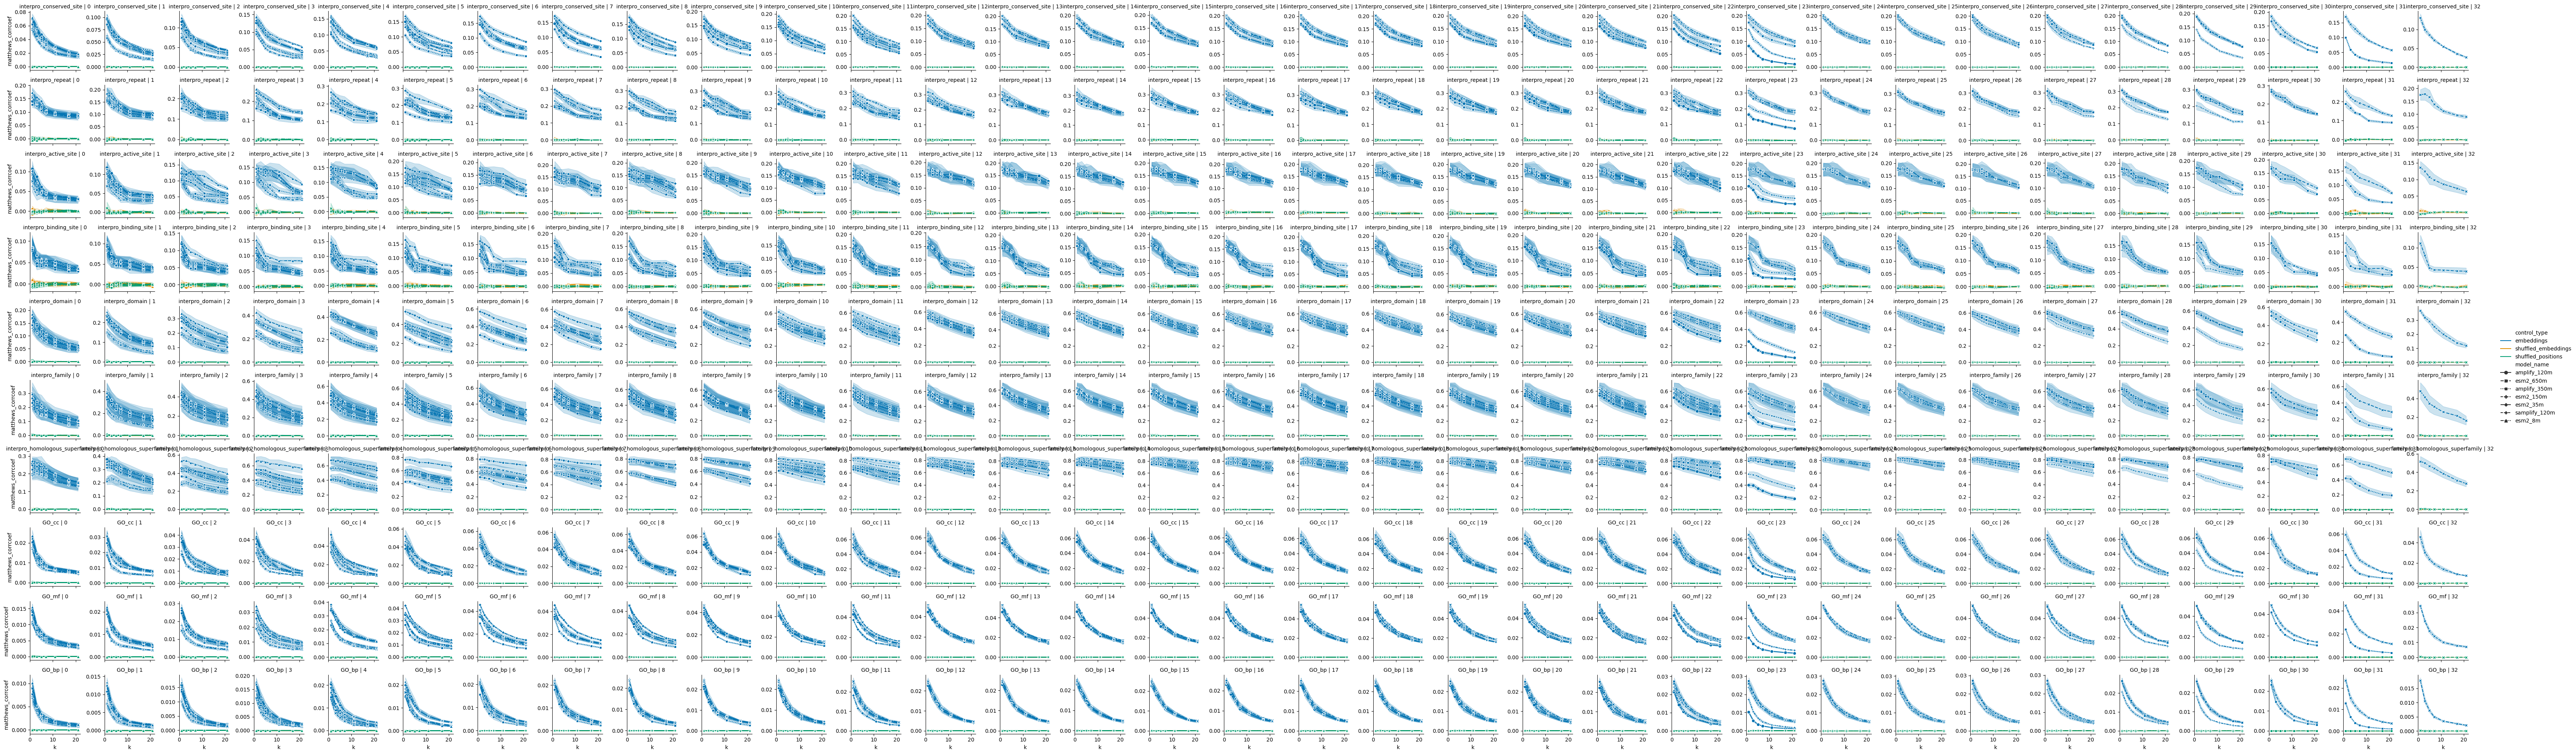

In [16]:
dataset = 'interpro_domain'
models = ['amplify_120m'] 
xaxis_var = 'layer_num'
embed_treatment = 'embeddings'
strategy = 'k'
distance_metric = 'euclidean'
weight_strategy = 'distance'
layer_nums = list(range(0,all_results['num_hiddens'].max() +1, 3))
relative_depths = [0.0, 0.2,0.4,0.6,1.0]

all_filters = [
    # pl.col('model_name').is_in(models), #uncomment to look at just the model specified in 'models' above
    # (pl.col('data') == dataset) #uncomment to look at just the dataset specified in 'dataset' above
    (pl.col('k').is_in(neighbor_ks)), # Filter by 'k' values
    (pl.col('weight_strategy') == weight_strategy),
    (pl.col('distance_metric') == distance_metric),
    # (pl.col('control_type') == embed_treatment), # uncomment to look at just the embeddings not the controls
    (pl.col(strategy) != -100),
    # (pl.col('layer_num').is_in(layer_nums))
    # (pl.col('relative_depth').is_in(relative_depths)) # uncomment to filter for relative depths specified above (note: risky! May not map perfectly due to rounding)
]
# Apply filters
combined_filter = reduce(lambda a, b: a & b, all_filters)
df_filtered = all_results.filter(combined_filter)

# Specify what we want to look at
xaxis_var = 'k'
color_by = 'control_type'
style_by = 'model_name'
col_by = 'layer_num'
row_by = 'dataset'
dataset_order = ['interpro_conserved_site', 'interpro_repeat', 'interpro_active_site', 'interpro_binding_site', 
                'interpro_domain', 'interpro_family', 'interpro_homologous_superfamily',
                'GO_cc', 'GO_mf', 'GO_bp']

# Choose to look at mcc because that's what we've generally been looking at, it should be a metric that best takes into account class imbalance 
score_metric = 'matthews_corrcoef' # coverage_error	label_ranking_average_precision_score	label_ranking_loss	f1_score_macro	precision_score_macro	recall_score_macro	jaccard_score_macro

fig = sns.relplot(data = df_filtered, 
    x= xaxis_var, 
    y = score_metric,
    col = col_by,
    row = row_by,
    row_order = dataset_order,
    kind = 'line', 
    markers=True,
    style=style_by,
    hue = color_by, 
    height = 2,
    palette = 'colorblind',
    facet_kws={'sharey': False},
    )
fig.set_titles(col_template='{col_name}', row_template='{row_name}')
fig.tight_layout()
fig.savefig(knn_figures_dir / f"knn_{weight_strategy}_{distance_metric}_{score_metric}_vs_{xaxis_var}_by_{style_by}_hue_{color_by}_grid_{col_by}_and_{row_by}.png")

Yes, for all layers looked at and models, the control is right down around 0 and the actual embeddings have some organization.

# Is there a difference per-model? Per-dataset (concept)? At different layers?

We'll try to look at models that are roughly the same size/number of parameters (amplify-120m & esm2-150m, amplify-350m & esm2-650m) for best comparability

There are too many layers to look at all at once, choose every 5 to start. Look layerwise because relative depth rounding errors make things maybe a bit less comparable, plus based on probing it seems that concept acquisition generally happens layerwise for the concepts we're looking at (for secondary structure there may be some relative depth dependence, but for most others we may acquire them by ~layer 12).

May be useful to get the last layer because PCA suggests that organization decreases heavily at the last layer, when models need to focus on predicting amino acid identity for the masked language modeling objective.

/tmp/ipykernel_485879/1302359338.py:26: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  df_filtered = all_results.filter(combined_filter)


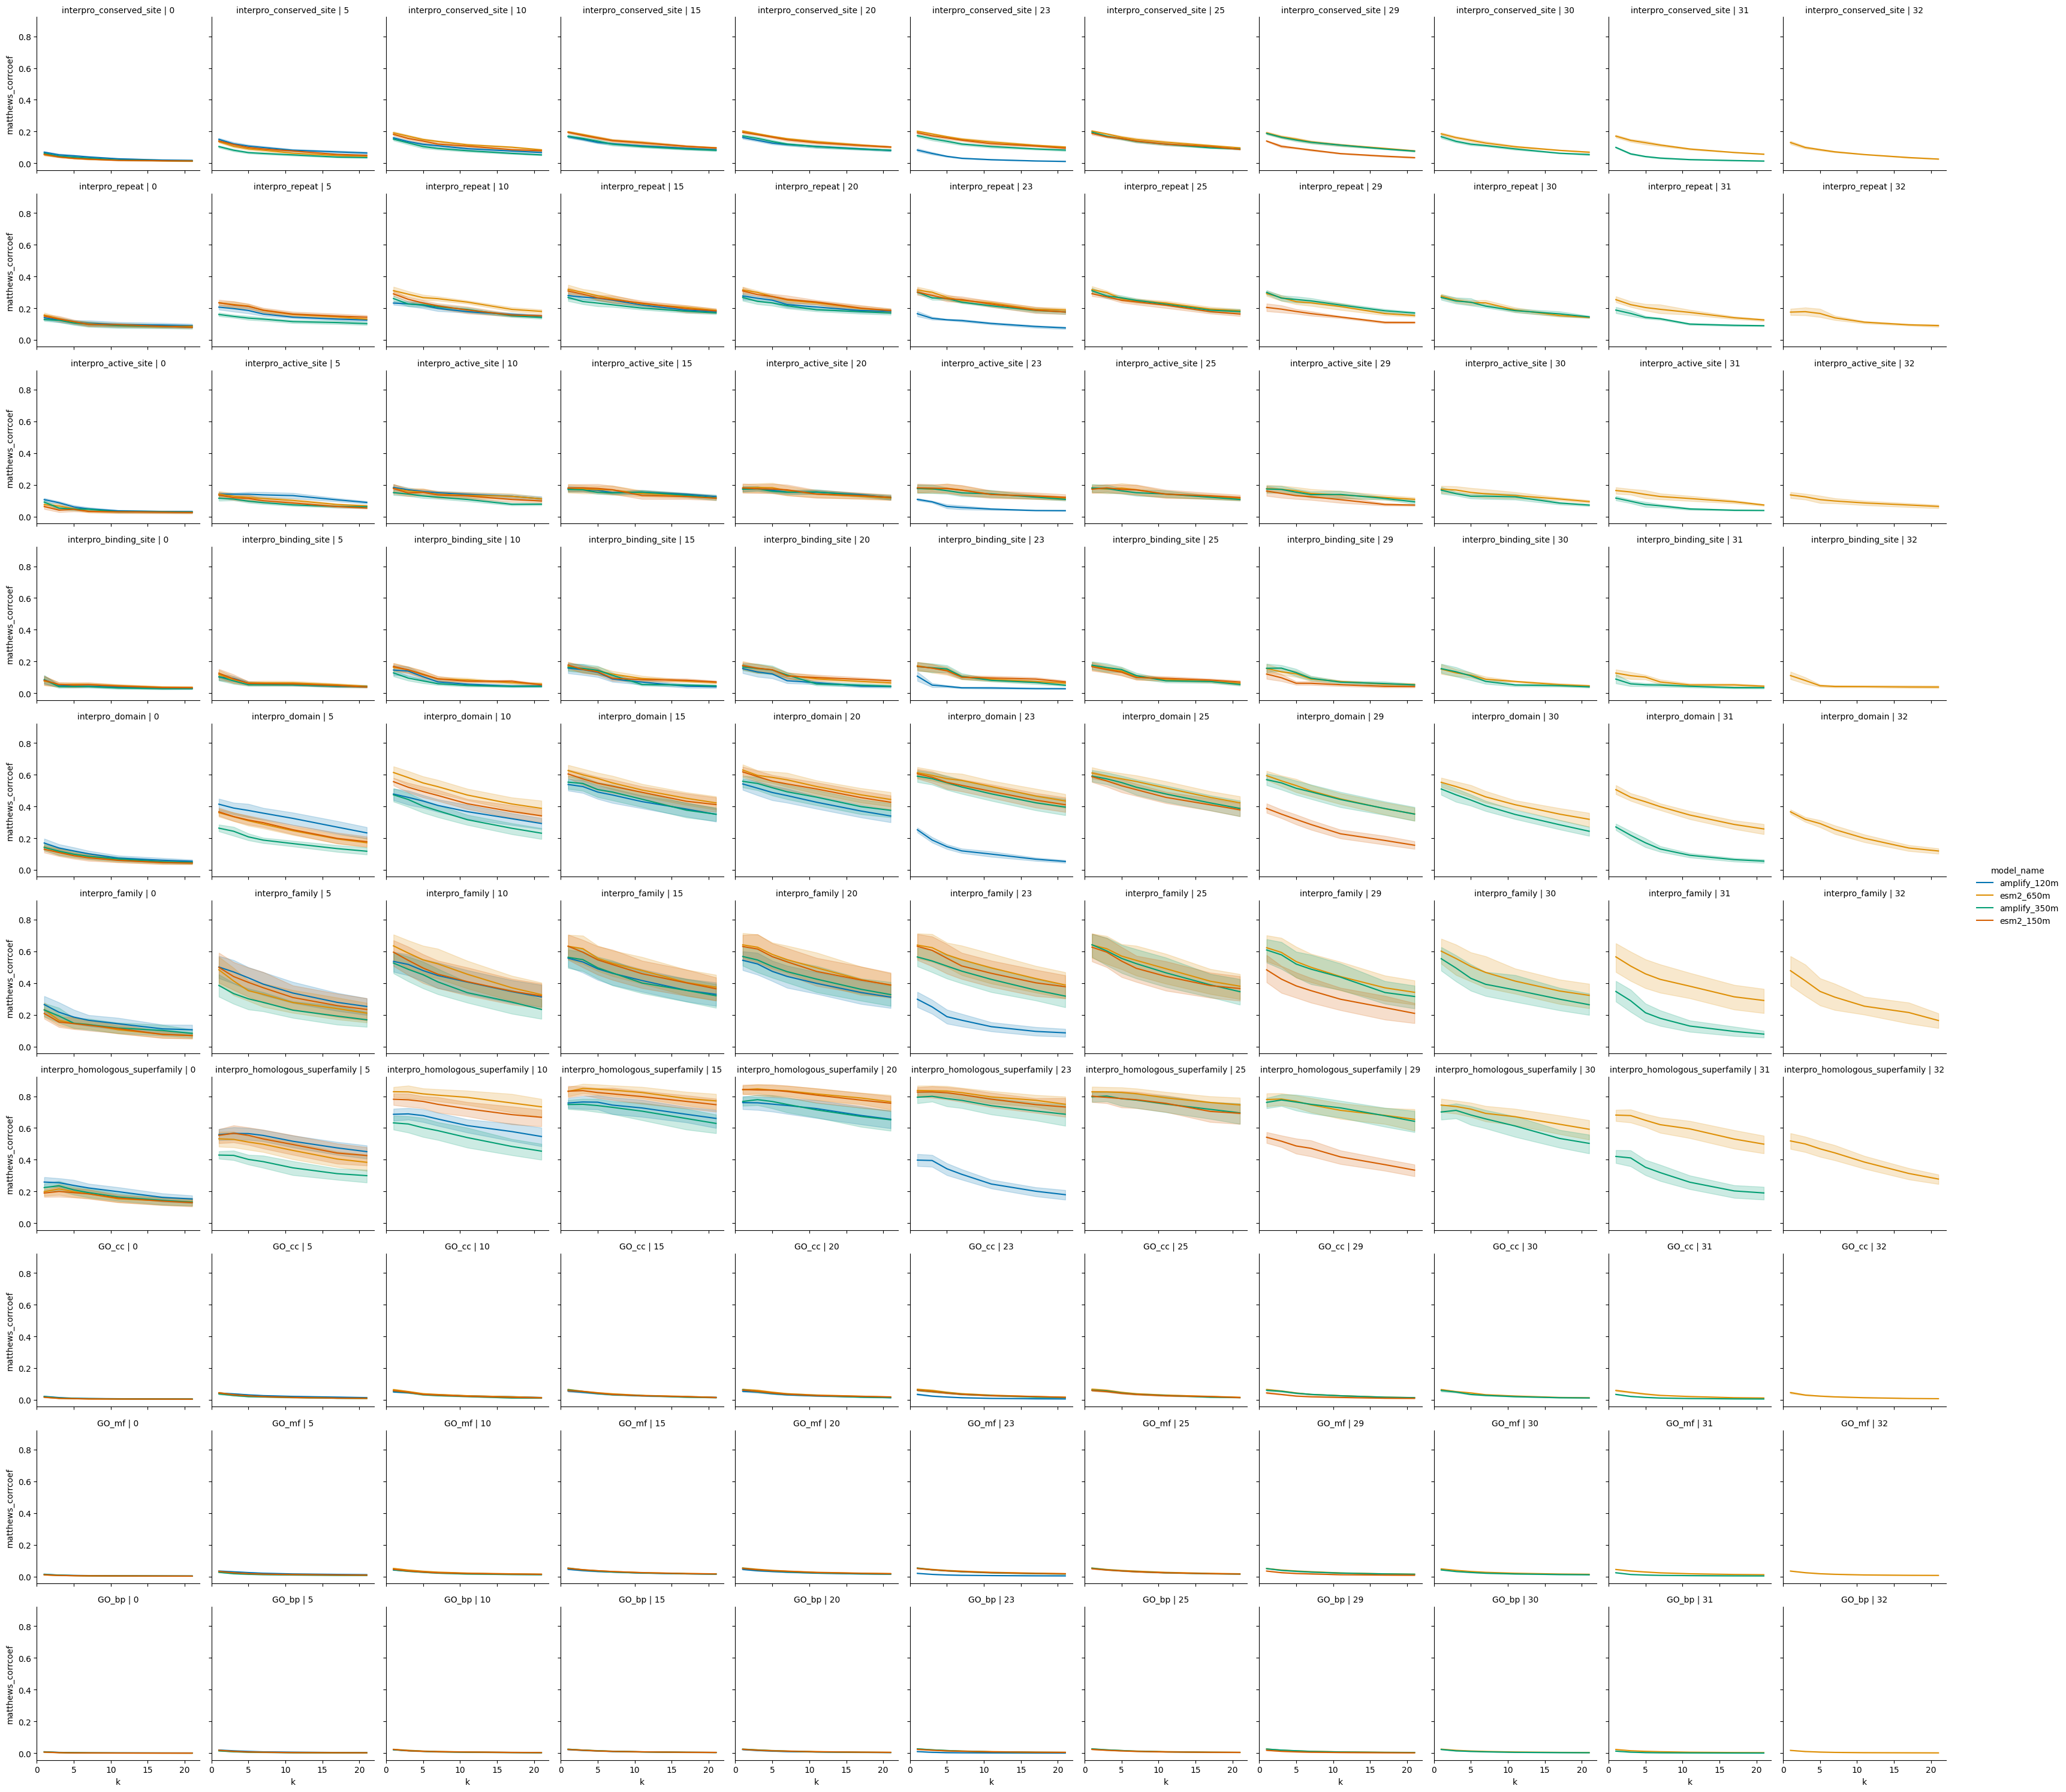

In [17]:
dataset = 'interpro_domain'
models = ['amplify_120m', 'amplify_350m', 'esm2_150m', 'esm2_650m']
xaxis_var = 'layer_num'
embed_treatment = 'embeddings'
strategy = 'k'
distance_metric = 'euclidean'
weight_strategy = 'distance'
last_layers_for_models = [plms[x]['num_hiddens']-1 for x in models] # Last layer numbers for each model
layer_interval = 5
layer_nums = sorted(list(set(list(range(0, max(last_layers_for_models) + 1, layer_interval)) + last_layers_for_models))) # Get both every [interval] layer and the last layer for each model
relative_depths = [0.0, 0.2,0.4,0.6,1.0]

all_filters = [
    pl.col('model_name').is_in(models), #uncomment to look at just the models specified in 'models' above
    # (pl.col('data') == dataset) #uncomment to look at just the dataset specified in 'dataset' above
    (pl.col('k').is_in(neighbor_ks)), # Filter by 'k' values
    (pl.col('weight_strategy') == weight_strategy),
    (pl.col('distance_metric') == distance_metric),
    (pl.col('control_type') == embed_treatment), # uncomment to look at just the embeddings not the controls
    (pl.col(strategy) != -100),
    (pl.col('layer_num').is_in(layer_nums))
    # (pl.col('relative_depth').is_in(relative_depths)) # uncomment to filter for relative depths specified above (note: risky! May not map perfectly due to rounding)
]
# Apply filters
combined_filter = reduce(lambda a, b: a & b, all_filters)
df_filtered = all_results.filter(combined_filter)

xaxis_var = 'k'
color_by = 'model_name'
col_by = 'layer_num'
row_by = 'dataset'
# style_by = 'model_name'
dataset_order = ['interpro_conserved_site', 'interpro_repeat', 'interpro_active_site', 'interpro_binding_site', 
                'interpro_domain', 'interpro_family', 'interpro_homologous_superfamily',
                'GO_cc', 'GO_mf', 'GO_bp']

score_metric = 'matthews_corrcoef' # coverage_error	label_ranking_average_precision_score	label_ranking_loss	f1_score_macro	precision_score_macro	recall_score_macro	jaccard_score_macro

fig = sns.relplot(data = df_filtered, 
    x= xaxis_var, 
    y = score_metric,
    col = col_by,
    row = row_by,
    row_order = dataset_order,
    kind = 'line', 
    markers=True,
    # style=style_by,
    hue = color_by, 
    height = 3,
    aspect = 1,
    palette = 'colorblind',
    facet_kws={'sharey': True},
    )
fig.set_titles(col_template='{col_name}', row_template='{row_name}')
fig.tight_layout()
fig.savefig(knn_figures_dir / f"knn_splits_{weight_strategy}_{distance_metric}_{score_metric}_vs_{xaxis_var}_{'_'.join(models)}_by_{style_by}_hue_{color_by}_grid_{col_by}_and_{row_by}.png")

### Quick observations:

Keep in mind that last layers are:

```
 {'amplify_120m': 23,
 'samplify_120m': 23,
 'amplify_350m': 31,
 'esm2_150m': 29,
 'esm2_650m': 32}
 ```

We expect to see a decrease in [basically whatever we're looking at] at the model's last layer.

**Knn interpretation**
- If we believe that k=1 is a very nonlinear boundary, and increasing k smoothes the boundary and makes it more linear, a sharp decrease followed by a gentle plateau should indicate where something may be nonlinear. This is most apparent for active site and binding site, regardless of model. For binding site this may make sense, since binding sites are dependent not only on the protein we're looking at but its binding partner, so it could be hinting at higher-order interactions.

**Model-wise** 
- All models start out with essentially the same level of organization (no difference in the curves at layer 0, they're basically overlapping)
- Smaller Amplify models start out with higher predictive ability across all k tested, and decrease closer to the end - at the last layer, we do see a drastic decrease in their performance.
- The biggest differences in performance between different models are with homologous superfamily, and maybe domain.

**Dataset-wise**
- GO labels are potentially much less grouped than interpro labels - they have lower scores overall, and the curves look different (as k increases, we see a bit of a bump and then potentially a gradual decrease)
- Homologous superfamily starts to look more like GO curves as we go further through the model (e.g. by layer 20)
- We would have to do stats to see if this apparent increase-decrease behaviour with GO terms is actually significant or some visual artifact.

In [18]:
dataset = 'interpro_domain'
models = ['amplify_120m', 'amplify_350m', 'esm2_150m', 'esm2_650m']
xaxis_var = 'layer_num'
embed_treatment = 'embeddings'
strategy = 'k'
distance_metric = 'euclidean'
weight_strategy = 'distance'
last_layers_for_models = [plms[x]['num_hiddens']-1 for x in models] # Last layer numbers for each model
layer_interval = 5
layer_nums = sorted(list(set(list(range(0, max(last_layers_for_models) + 1, layer_interval)) + last_layers_for_models))) # Get both every [interval] layer and the last layer for each model
relative_depths = [0.0, 0.2,0.4,0.6,1.0]

all_filters = [
    pl.col('model_name').is_in(models), #uncomment to look at just the models specified in 'models' above
    # (pl.col('data') == dataset) #uncomment to look at just the dataset specified in 'dataset' above
    (pl.col('k').is_in(neighbor_ks)), # Filter by 'k' values
    (pl.col('weight_strategy') == weight_strategy),
    (pl.col('distance_metric') == distance_metric),
    (pl.col('control_type') == embed_treatment), # uncomment to look at just the embeddings not the controls
    (pl.col(strategy) != -100),
    (pl.col('layer_num').is_in(layer_nums))
    # (pl.col('relative_depth').is_in(relative_depths)) # uncomment to filter for relative depths specified above (note: risky! May not map perfectly due to rounding)
]
# Apply filters
combined_filter = reduce(lambda a, b: a & b, all_filters)
df_filtered = all_results.filter(combined_filter)

xaxis_var = 'k'
color_by = 'model_name'
col_by = 'layer_num'
row_by = 'dataset'
# style_by = 'model_name'
dataset_order = ['interpro_conserved_site', 'interpro_repeat', 'interpro_active_site', 'interpro_binding_site', 
                'interpro_domain', 'interpro_family', 'interpro_homologous_superfamily',
                'GO_cc', 'GO_mf', 'GO_bp']

score_metric = 'matthews_corrcoef_macro' # coverage_error	label_ranking_average_precision_score	label_ranking_loss	f1_score_macro	precision_score_macro	recall_score_macro	jaccard_score_macro

fig = sns.relplot(data = df_filtered, 
    x= xaxis_var, 
    y = score_metric,
    col = col_by,
    row = row_by,
    row_order = dataset_order,
    kind = 'line', 
    markers=True,
    # style=style_by,
    hue = color_by, 
    height = 3,
    aspect = 1,
    palette = 'colorblind',
    facet_kws={'sharey': True},
    )
fig.set_titles(col_template='{col_name}', row_template='{row_name}')
fig.tight_layout()
fig.savefig(knn_figures_dir / f"knn_splits_{weight_strategy}_{distance_metric}_{score_metric}_vs_{xaxis_var}_{'_'.join(models)}_by_{style_by}_hue_{color_by}_grid_{col_by}_and_{row_by}.png")

/tmp/ipykernel_485879/322512175.py:26: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  df_filtered = all_results.filter(combined_filter)


ValueError: Could not interpret value `matthews_corrcoef_macro` for `y`. An entry with this name does not appear in `data`.

/tmp/ipykernel_350522/4170006476.py:29: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  df_filtered = all_results.filter(combined_filter)
/tmp/ipykernel_350522/4170006476.py:29: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  df_filtered = all_results.filter(combined_filter)
/tmp/ipykernel_350522/4170006476.py:29: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  df_filtered = all_results.filter(combined_filter)
/tmp/ipykernel_350522/4170006476.py:29: DeprecationWarn

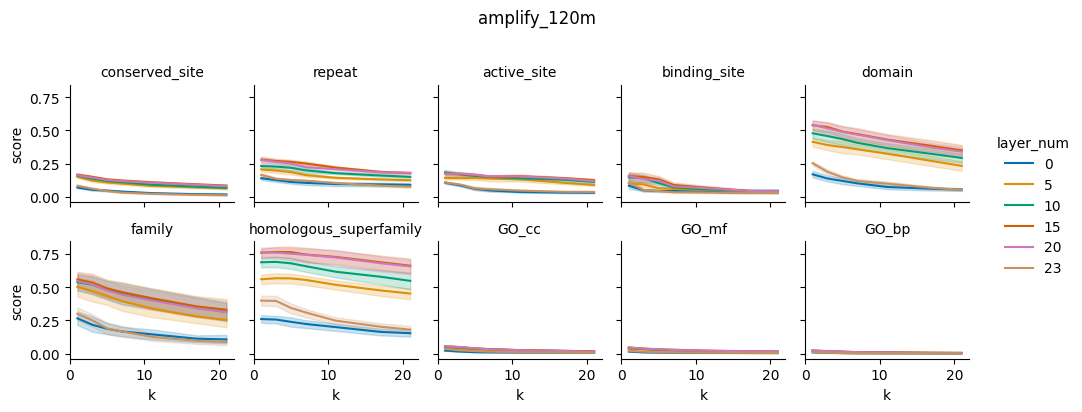

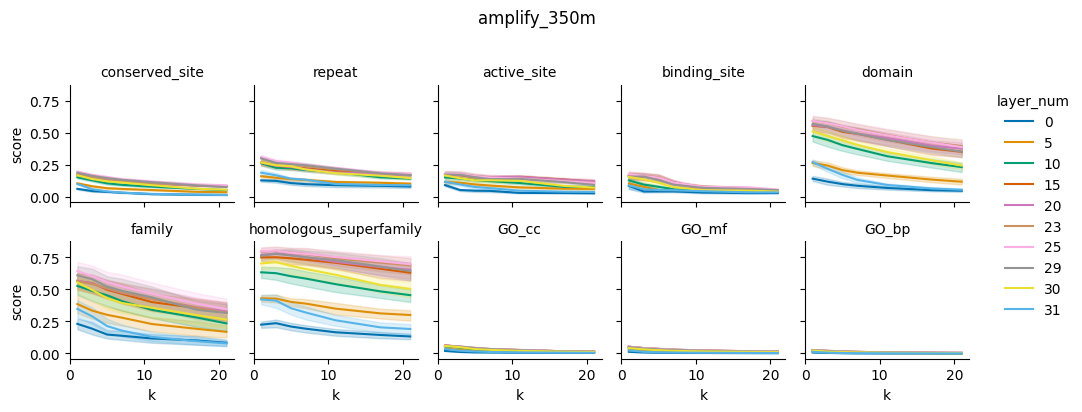

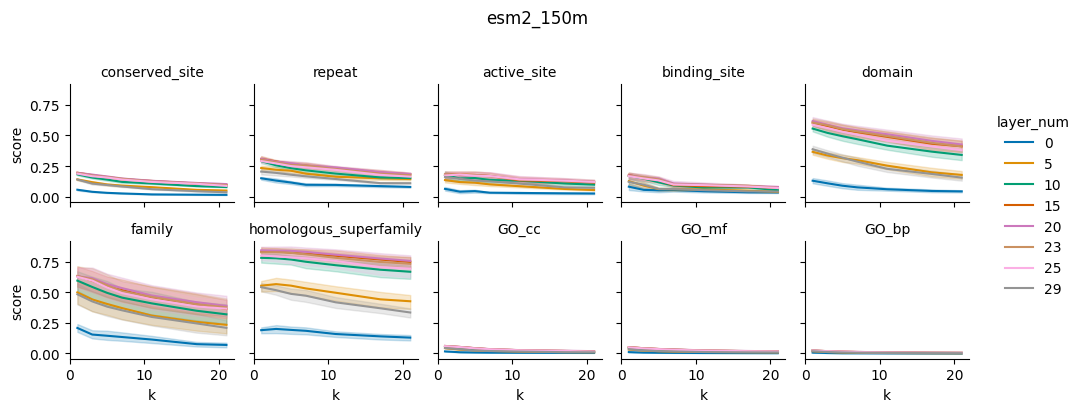

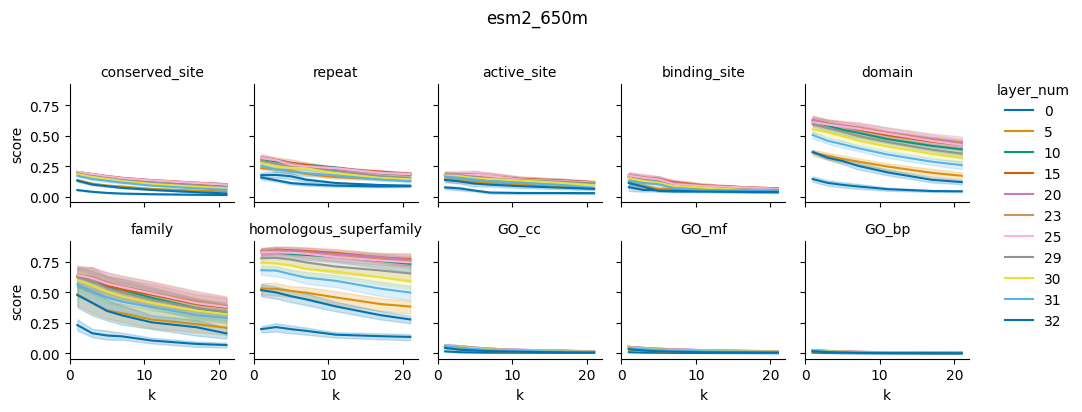

In [ ]:
dataset = 'interpro_domain'
models = ['amplify_120m', 'amplify_350m', 'esm2_150m', 'esm2_650m']
xaxis_var = 'layer_num'
embed_treatment = 'embeddings'
strategy = 'k'
distance_metric = 'euclidean'
weight_strategy = 'distance'
last_layers_for_models = [plms[x]['num_hiddens']-1 for x in models] # Last layer numbers for each model
layer_interval = 5
layer_nums = sorted(list(set(list(range(0, max(last_layers_for_models) + 1, layer_interval)) + last_layers_for_models))) # Get both every [interval] layer and the last layer for each model
relative_depths = [0.0, 0.2,0.4,0.6,1.0]

# Loop over models
for model in models:
    all_filters = [
        pl.col('model_name') == model, #uncomment to look at just the models specified in 'models' above
        # (pl.col('data') == dataset) #uncomment to look at just the dataset specified in 'dataset' above
        (pl.col('k').is_in(neighbor_ks)), # Filter by 'k' values
        (pl.col('weight_strategy') == weight_strategy),
        (pl.col('distance_metric') == distance_metric),
        (pl.col('control_type') == embed_treatment), # uncomment to look at just the embeddings not the controls
        (pl.col(strategy) != -100),
        (pl.col('layer_num').is_in(layer_nums))
        # (pl.col('relative_depth').is_in(relative_depths)) # uncomment to filter for relative depths specified above (note: risky! May not map perfectly due to rounding)
    ]
    # Apply filters
    combined_filter = reduce(lambda a, b: a & b, all_filters)
    df_filtered = all_results.filter(combined_filter)

    dataset_regex = r"(uniprot_|interpro_|biomap_)"

    xaxis_var = 'k'
    color_by = 'layer_num'
    col_by = 'dataset'
    col_wrap_num = 5
    # row_by = 'dataset'
    # style_by = 'model_name'
    dataset_order = ['interpro_conserved_site', 'interpro_repeat', 'interpro_active_site', 'interpro_binding_site', 
                    'interpro_domain', 'interpro_family', 'interpro_homologous_superfamily',
                    'GO_cc', 'GO_mf', 'GO_bp']

    score_metric = 'matthews_corrcoef' # coverage_error	label_ranking_average_precision_score	label_ranking_loss	f1_score_macro	precision_score_macro	recall_score_macro	jaccard_score_macro

    # Create grayscale palette for layer_num (light grey to black, ordered by layer_num)
    unique_layers = sorted(df_filtered['layer_num'].unique().to_list())
    n_layers = len(unique_layers)
    # Use Greys palette: lighter = lower layers, darker = higher layers
    grayscale_palette = sns.color_palette("Greys", n_colors=n_layers)

    fig = sns.relplot(data = df_filtered.with_columns(
            pl.col("dataset").str.replace_all(dataset_regex, "")).rename({score_metric: 'score'}), # Adjust dataset names for showing in figure, 
        x= xaxis_var, 
        y = 'score',
        col = col_by,
        col_order = [re.sub(dataset_regex, "", i) for i in dataset_order],
        col_wrap=col_wrap_num,
        # row = row_by,
        # row_order = dataset_order,
        kind = 'line', 
        markers=True,
        # style=style_by,
        hue = color_by, 
        hue_order = unique_layers,
        height = 2,
        aspect = 1,
        palette = 'colorblind',
        facet_kws={'sharey': True},
        )
    fig.set_titles(col_template='{col_name}', row_template='{row_name}')
    fig.fig.suptitle(model, y=1.02)
    fig.tight_layout()
    fig.savefig(knn_figures_dir / f"knn_splits_{model}_condensedK_{weight_strategy}_{distance_metric}_{score_metric}_vs_{xaxis_var}_hue_{color_by}_grid_{col_by}.png")

/tmp/ipykernel_350522/1884677490.py:29: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  df_filtered = all_results.filter(combined_filter)
/tmp/ipykernel_350522/1884677490.py:29: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  df_filtered = all_results.filter(combined_filter)
/tmp/ipykernel_350522/1884677490.py:29: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  df_filtered = all_results.filter(combined_filter)
/tmp/ipykernel_350522/1884677490.py:29: DeprecationWarn

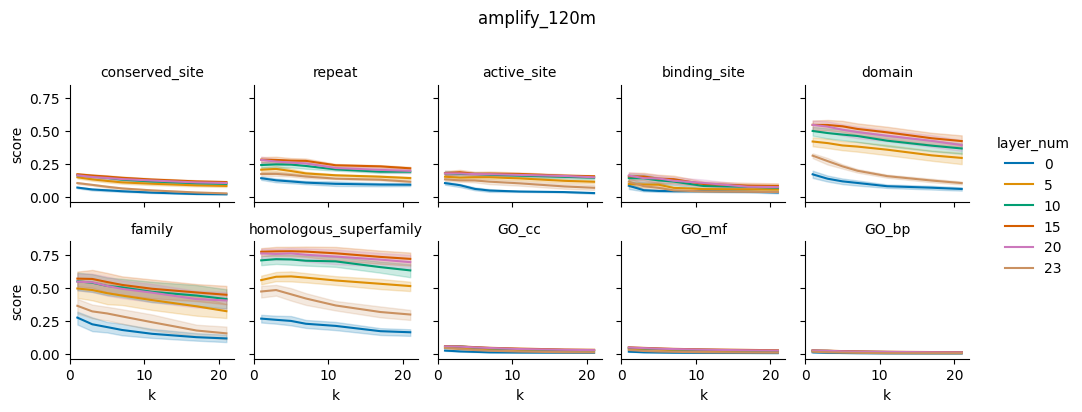

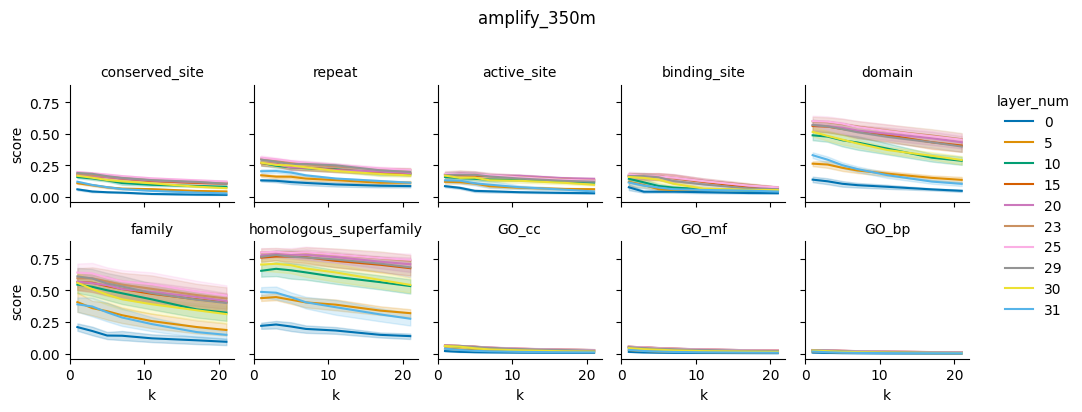

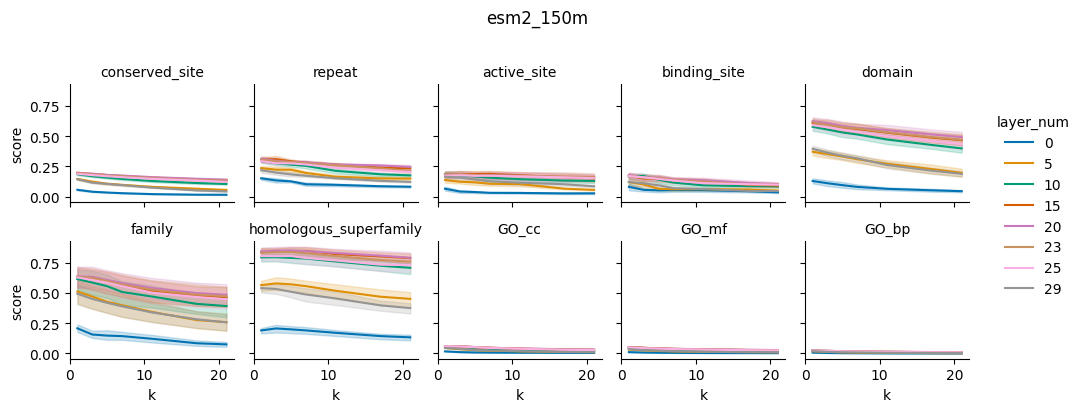

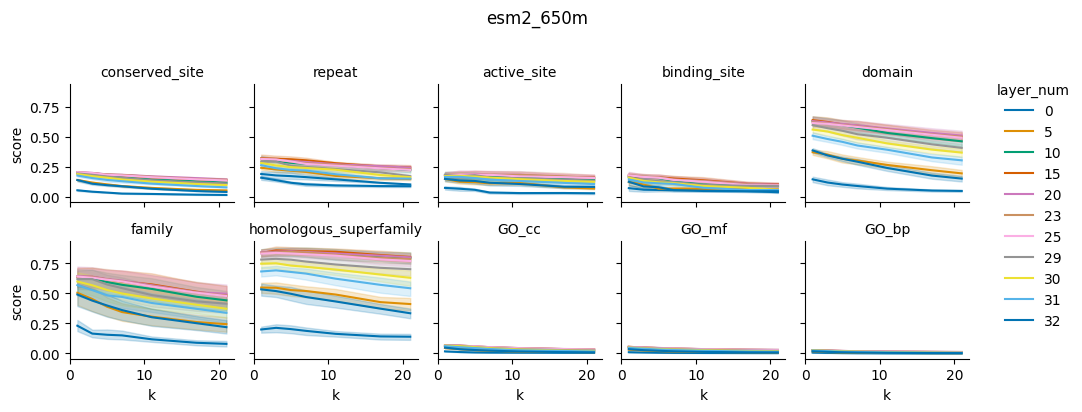

In [ ]:
dataset = 'interpro_domain'
models = ['amplify_120m', 'amplify_350m', 'esm2_150m', 'esm2_650m']
xaxis_var = 'layer_num'
embed_treatment = 'embeddings'
strategy = 'k'
distance_metric = 'cosine'
weight_strategy = 'distance'
last_layers_for_models = [plms[x]['num_hiddens']-1 for x in models] # Last layer numbers for each model
layer_interval = 5
layer_nums = sorted(list(set(list(range(0, max(last_layers_for_models) + 1, layer_interval)) + last_layers_for_models))) # Get both every [interval] layer and the last layer for each model
relative_depths = [0.0, 0.2,0.4,0.6,1.0]

# Loop over models
for model in models:
    all_filters = [
        pl.col('model_name') == model, #uncomment to look at just the models specified in 'models' above
        # (pl.col('data') == dataset) #uncomment to look at just the dataset specified in 'dataset' above
        (pl.col('k').is_in(neighbor_ks)), # Filter by 'k' values
        (pl.col('weight_strategy') == weight_strategy),
        (pl.col('distance_metric') == distance_metric),
        (pl.col('control_type') == embed_treatment), # uncomment to look at just the embeddings not the controls
        (pl.col(strategy) != -100),
        (pl.col('layer_num').is_in(layer_nums))
        # (pl.col('relative_depth').is_in(relative_depths)) # uncomment to filter for relative depths specified above (note: risky! May not map perfectly due to rounding)
    ]
    # Apply filters
    combined_filter = reduce(lambda a, b: a & b, all_filters)
    df_filtered = all_results.filter(combined_filter)

    dataset_regex = r"(uniprot_|interpro_|biomap_)"

    xaxis_var = 'k'
    color_by = 'layer_num'
    col_by = 'dataset'
    col_wrap_num = 5
    # row_by = 'dataset'
    # style_by = 'model_name'
    dataset_order = ['interpro_conserved_site', 'interpro_repeat', 'interpro_active_site', 'interpro_binding_site', 
                    'interpro_domain', 'interpro_family', 'interpro_homologous_superfamily',
                    'GO_cc', 'GO_mf', 'GO_bp']

    score_metric = 'matthews_corrcoef' # coverage_error	label_ranking_average_precision_score	label_ranking_loss	f1_score_macro	precision_score_macro	recall_score_macro	jaccard_score_macro

    # Create grayscale palette for layer_num (light grey to black, ordered by layer_num)
    unique_layers = sorted(df_filtered['layer_num'].unique().to_list())
    n_layers = len(unique_layers)
    # Use Greys palette: lighter = lower layers, darker = higher layers
    grayscale_palette = sns.color_palette("Greys", n_colors=n_layers)

    fig = sns.relplot(data = df_filtered.with_columns(
            pl.col("dataset").str.replace_all(dataset_regex, "")).rename({score_metric: 'score'}), # Adjust dataset names for showing in figure, 
        x= xaxis_var, 
        y = 'score',
        col = col_by,
        col_order = [re.sub(dataset_regex, "", i) for i in dataset_order],
        col_wrap=col_wrap_num,
        # row = row_by,
        # row_order = dataset_order,
        kind = 'line', 
        markers=True,
        # style=style_by,
        hue = color_by, 
        hue_order = unique_layers,
        height = 2,
        aspect = 1,
        palette = 'colorblind',
        facet_kws={'sharey': True},
        )
    fig.set_titles(col_template='{col_name}', row_template='{row_name}')
    fig.fig.suptitle(model, y=1.02)
    fig.tight_layout()
    fig.savefig(knn_fig_dir / f"knn_splits_{model}_condensedK_{weight_strategy}_{distance_metric}_{score_metric}_vs_{xaxis_var}_hue_{color_by}_grid_{col_by}.png")